**Question 1 : What is the difference between multithreading and multiprocessing?**

**Answer:** The difference between multithreading and multiprocessing comes down to memory sharing and how tasks execute on CPU cores.

> Multithreading runs multiple threads within a single process, sharing the same memory space.

1. Memory: All threads share the same heap memory and address space of the parent process.

2. Execution & Overhead: Lightweight to create and switch between (low CPU/memory overhead).

3. Python Constraint (The GIL): Due to Python's Global Interpreter Lock (GIL) in standard CPython, only one thread can execute Python bytecode at a time.

4. Best Used For: I/O-bound tasks (network requests, file reading/writing, database queries) where threads spend most of their time waiting for external responses.
    
> Multiprocessing runs multiple independent processes, each with its own dedicated memory space and Python interpreter instance.

1. Memory: Each process gets its own completely isolated memory allocation. Data sharing requires Inter-Process Communication (IPC) such as Queues or Pipes.

2. Execution & Overhead: Heavier to spawn and manage, but achieves true parallelism across multiple CPU cores.

3. GIL Bypass: Completely bypasses the GIL because each process runs its own separate Python interpreter.

4. Best Used For: CPU-bound tasks (heavy math, data processing, machine learning, image rendering) that require continuous computing power.

**Question 2: What are the challenges associated with memory management in Python**

**Answer:** Python handles memory allocation and deallocation automatically through reference counting and a cyclic garbage collector (GC). While this abstracts away manual memory management (like malloc and free in C), it introduces distinct performance and operational challenges in large-scale applications:

1. Python's primary deallocation method is reference counting. When an object's reference count drops to zero, it is immediately freed. However, if two or more objects reference each other (e.g., node A references node B, and node B references node A), their reference counts never hit zero—even if the application has lost all access to them.

2. The cyclic GC runs periodically based on object allocation thresholds. When scanning generation 2 (long-lived objects), the GC must freeze execution to traverse object graphs.

3. Python uses an internal memory allocator called PyMalloc for small objects (up to 512 bytes). When these objects are deleted, PyMalloc frees the memory inside its internal arenas, but it frequently does not return that memory back to the Operating System.

4. In CPython, everything is a full heap-allocated object (PyObject), carrying metadata such as type pointers and reference counters.

5. Because the GIL restricts multithreading for CPU-heavy tasks, Python developers rely on multiprocessing. When using fork(), processes initially share memory via Copy-on-Write (CoW).

In [1]:
'''
Question 3:Write a Python program that logs an error message to a log file when a division by zero exception occurs.
'''
import logging

# Configure the logging settings
logging.basicConfig(
    filename="app_errors.log",
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s",
)


def safe_divide(numerator, denominator):
    try:
        result = numerator / denominator
        return result
    except ZeroDivisionError as e:
        # Log the error along with the full traceback using exc_info=True
        logging.error(
            f"Division by zero attempted: {numerator} / {denominator}",
            exc_info=True,
        )
        print("An error occurred. Check 'app_errors.log' for details.")
        return None


# Test the function
safe_divide(10, 2)  # Successful execution (not logged)
safe_divide(10, 0)

ERROR:root:Division by zero attempted: 10 / 0
Traceback (most recent call last):
  File "/tmp/ipykernel_524/4219185100.py", line 16, in safe_divide
    result = numerator / denominator
             ~~~~~~~~~~^~~~~~~~~~~~~
ZeroDivisionError: division by zero


An error occurred. Check 'app_errors.log' for details.


In [3]:
'''
Question 4:Write a Python program that reads from one file and writes its content to
another file.
'''
with open("input.txt", "w") as f:
    f.write("Hello, this is line 1.\n")
    f.write("Python file handling works!\n")

print("Created 'input.txt' successfully.")

def copy_file(source_file, destination_file):
    try:
        # Open source file for reading and destination file for writing
        with open(source_file, "r") as src, open(destination_file, "w") as dst:
            for line in src:
                dst.write(line)
        print(f"Successfully copied content from '{source_file}' to '{destination_file}'.")

    except FileNotFoundError:
        print(f"Error: The file '{source_file}' does not exist.")
    except PermissionError:
        print("Error: Permission denied while accessing one of the files.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


# Example usage:
copy_file("input.txt", "output.txt")

Created 'input.txt' successfully.
Successfully copied content from 'input.txt' to 'output.txt'.


In [4]:
'''
Question 5: Write a program that handles both IndexError and KeyError using a
try-except block.
'''

def retrieve_data(items_list, user_dict, index, key):
    try:
        # Accessing an element by index (can trigger IndexError)
        list_value = items_list[index]
        print(f"List item at index {index}: {list_value}")

        # Accessing a dictionary value by key (can trigger KeyError)
        dict_value = user_dict[key]
        print(f"Dictionary value for key '{key}': {dict_value}")

    except IndexError as e:
        print(f"IndexError caught: Index {index} is out of range. ({e})")

    except KeyError as e:
        print(f"KeyError caught: Key {e} does not exist in the dictionary.")

    except Exception as e:
        print(f"An unexpected error occurred: {e}")


# Sample data
colors = ["red", "green", "blue"]
user_info = {"name": "Alice", "role": "Developer"}

# 1. Normal run (both valid)
print("--- Test 1: Valid access ---")
retrieve_data(colors, user_info, 1, "name")

# 2. Triggering IndexError (index 5 does not exist)
print("\n--- Test 2: Triggering IndexError ---")
retrieve_data(colors, user_info, 5, "name")

# 3. Triggering KeyError ('age' key does not exist)
print("\n--- Test 3: Triggering KeyError ---")
retrieve_data(colors, user_info, 0, "age")

--- Test 1: Valid access ---
List item at index 1: green
Dictionary value for key 'name': Alice

--- Test 2: Triggering IndexError ---
IndexError caught: Index 5 is out of range. (list index out of range)

--- Test 3: Triggering KeyError ---
List item at index 0: red
KeyError caught: Key 'age' does not exist in the dictionary.


**Question 6: What are the differences between NumPy arrays and Python lists?**

**Answr:** NumPy arrays (ndarray) and Python lists both store collections of elements, but they are architecturally different under the hood, targeting distinct use cases:

**1. Data Type Homogeneity:**

Python Lists: Heterogeneous. A single list can hold a mix of integers, strings, objects, and floats (e.g., [1, "hello", 3.14, True]).

NumPy Arrays: Strictly homogeneous. All elements must share the exact same data type (e.g., int32, float64). If you insert mixed types, NumPy upcasts them to a common type (often string or float).

**2. Memory Layout and Efficiency:**

Python Lists: An array of pointers (references) pointing to full PyObject wrappers scattered across heap memory. This adds significant per-element memory overhead and causes cache misses.

NumPy Arrays: Stored as a single, contiguous block of raw memory (like C arrays) without Python object wrappers, dramatically reducing RAM usage.

**3. Execution Speed and Vectorization**

Python Lists: Element-wise mathematical operations require explicit Python loops or list comprehensions, which incur interpreter overhead for dynamic type-checking on every iteration.

NumPy Arrays: Support vectorized operations executed at C/Fortran speeds without Python loop overhead, running anywhere from 10x to 100x faster for large datasets.

**Question 7:Explain the difference between apply() and map() in Pandas.**

**Answer:** map() and apply() in Pandas are both used to transform data, but they differ in what objects they operate on, what inputs they accept, and how they execute transformations.

1. map() (Value Mapping & Element-Wise Transformations)

Where it applies: Exclusively element-wise on a Series (or across individual cells of a DataFrame as of Pandas 2.1+).  

Inputs accepted: Functions, Python dictionaries, or another Series.

Best use case: Substituting values from one domain to another (e.g., categorical encoding, replacing keys with dictionary values).

Behavior with dictionaries: Keys not present in the dictionary are mapped to NaN.

2. apply() (Complex Operations & Row/Column Execution)

Where it applies: Works on both a Series (element-wise) and a DataFrame (across entire rows or columns).

Inputs accepted: Functions only (standard functions or lambda). It cannot accept dictionaries or lookup mappings directly.

Best use case: Complex mathematical calculations, string manipulations requiring multiple parameters, row-level conditions spanning multiple columns, and aggregations (e.g., axis=0 for columns, axis=1 for rows).

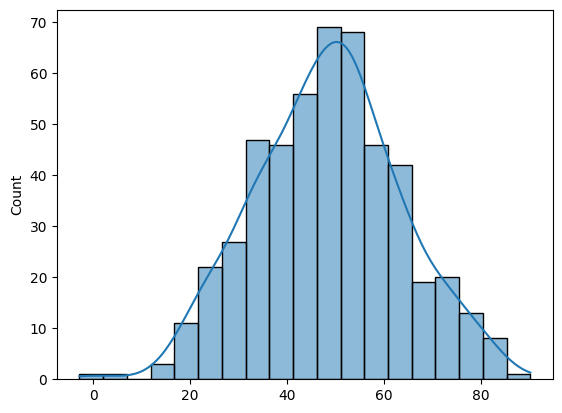

In [5]:
#Question 8: Create a histogram using Seaborn to visualize a distribution.

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate sample data
data = np.random.normal(loc=50, scale=15, size=500)

# Create a clean histogram with a KDE curve
sns.histplot(data, kde=True)

# Display the plot
plt.show()

In [7]:
#Question 9: Use Pandas to load a CSV file and display its first 5 rows

import pandas as pd

# 1. Create and save a sample DataFrame as a CSV file
data = {
    "Name": ["Alice", "Bob", "Charlie", "Diana", "Evan", "Fiona"],
    "Age": [25, 30, 35, 28, 40, 22],
    "City": ["New York", "London", "Paris", "Tokyo", "Berlin", "Sydney"],
}
pd.DataFrame(data).to_csv("data.csv", index=False)

# 2. Read the CSV file and display the first 5 rows
df = pd.read_csv("data.csv")
print(df.head())

      Name  Age      City
0    Alice   25  New York
1      Bob   30    London
2  Charlie   35     Paris
3    Diana   28     Tokyo
4     Evan   40    Berlin


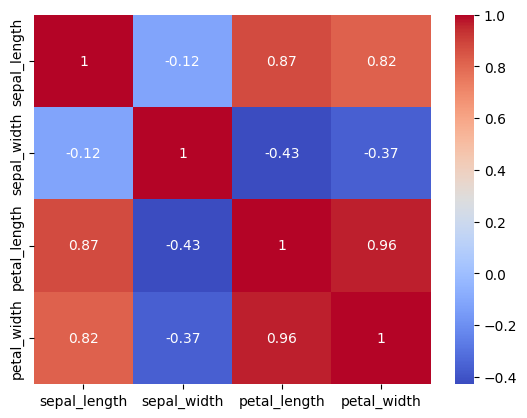

In [8]:
#Question 10: Calculate the correlation matrix using Seaborn and visualize it with a heatmap.

import matplotlib.pyplot as plt
import seaborn as sns

# Load a built-in numeric dataset
df = sns.load_dataset("iris").drop(columns=["species"])

# Calculate Pearson correlation matrix
corr_matrix = df.corr()

# Visualize with a heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.show()